# Build Rashomon Set for `diagonal_60x60`

This notebook loads a trained source policy for the `diagonal_60x60` layout, rolls out the source trajectory, and computes a Rashomon set from that trajectory.

In [1]:
import os
import sys
import copy
from pathlib import Path
import pandas
import torch
import yaml

os.environ.setdefault("SDL_AUDIODRIVER", "dummy")

def find_repo_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / ".git").exists():
            return path
    raise FileNotFoundError("Could not locate repo root containing .git")

repo_root = find_repo_root(Path.cwd())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from rl_project.experiments.frozenlake_scaled.train_source_policy import build_actor_critic, make_env_from_layout
from rl_project.experiments.frozenlake_scaled.downstream_adaptation_rashomon import (
    create_source_trajectory_rashomon_dataset,
    compute_rashomon_bounds,
)
from src.utils.general import sort_parameter_bounds_by_width
from rl_project.utils.rashomon_utils import plot_param_bounds, plot_param_bounds_per_checkpoint

%load_ext autoreload
%autoreload 2

print(f"Repo root: {repo_root}")

Repo root: /vol/bitbucket/ma5923/_projects/CertifiedContinualLearning


In [2]:
layout = "diagonal_60x60"
seed = 0
device = "cpu"

settings_dir = repo_root / "rl_project/experiments/frozenlake_scaled/settings"
source_env_file = settings_dir / "source_envs.yaml"
source_settings_file = settings_dir / "train_source_policy_settings.yaml"
adapt_settings_file = settings_dir / "downstream_adaptation_settings_ppo.yaml"
rashomon_settings_file = settings_dir / "downstream_adaptation_settings_rashomon.yaml"

outputs_candidates = [
    repo_root / "rl_project/experiments/frozenlake_scaled/outputs",
]

def find_source_run_dir(layout_name: str, run_seed: int) -> Path:
    for root in outputs_candidates:
        candidate = root / layout_name / f"seed_{run_seed}" / "source"
        if (candidate / "actor.pt").exists():
            return candidate
    searched = "\n".join(str(root / layout_name / f"seed_{run_seed}" / "source") for root in outputs_candidates)
    raise FileNotFoundError(f"Could not find source run dir with actor.pt. Searched:\n{searched}")

source_run_dir = find_source_run_dir(layout, seed)
artifact_dir = repo_root / "rl_project/experiments/frozenlake_scaled/notebooks/artifacts" / layout / f"seed_{seed}"
artifact_dir.mkdir(parents=True, exist_ok=True)

print(f"Source checkpoint dir: {source_run_dir}")
print(f"Notebook artifact dir: {artifact_dir}")

Source checkpoint dir: /vol/bitbucket/ma5923/_projects/CertifiedContinualLearning/rl_project/experiments/frozenlake_scaled/outputs/diagonal_60x60/seed_0/source
Notebook artifact dir: /vol/bitbucket/ma5923/_projects/CertifiedContinualLearning/rl_project/experiments/frozenlake_scaled/notebooks/artifacts/diagonal_60x60/seed_0


In [3]:
source_envs = yaml.safe_load(source_env_file.read_text(encoding="utf-8"))
source_settings = yaml.safe_load(source_settings_file.read_text(encoding="utf-8"))
adapt_settings = yaml.safe_load(adapt_settings_file.read_text(encoding="utf-8"))
rashomon_settings = yaml.safe_load(rashomon_settings_file.read_text(encoding="utf-8"))

source_cfg = source_envs[layout]
source_setting_cfg = source_settings[layout]
adapt_cfg = adapt_settings[layout]
rashomon_cfg = rashomon_settings[layout]["rashomon"]

source_map = source_cfg["env1_map"]
max_episode_steps = int(source_cfg["max_episode_steps"])
source_task_num = float(adapt_cfg.get("source_task_num", 0.0))
hidden = int(source_setting_cfg["ppo"]["hidden"])
activation = str(source_setting_cfg.get("activation", adapt_cfg.get("activation", "relu")))

rashomon_n_iters = 1_000 # int(rashomon_cfg.get("rashomon_n_iters", 100000))
inverse_temp_start = int(rashomon_cfg.get("inverse_temp_start", 10))
inverse_temp_max = int(rashomon_cfg.get("inverse_temp_max", 1000))
rashomon_checkpoint = int(rashomon_cfg.get("rashomon_checkpoint", 100))
surrogate_aggregation = "min"

print(f"Layout: {layout}")
print(f"Source task number: {source_task_num}")
print(f"Activation: {activation} | Hidden size: {hidden}")
print(
    f"Rashomon config => n_iters={rashomon_n_iters}, inverse_temp_start={inverse_temp_start}, "
    f"inverse_temp_max={inverse_temp_max}, checkpoint={rashomon_checkpoint}, aggregation={surrogate_aggregation}"
)

Layout: diagonal_60x60
Source task number: 0.0
Activation: relu | Hidden size: 128
Rashomon config => n_iters=1000, inverse_temp_start=10, inverse_temp_max=1000, checkpoint=100, aggregation=min


In [4]:
source_env_for_dim = make_env_from_layout(
    source_map,
    max_episode_steps,
    task_num=source_task_num,
    shaped=False,
)
obs_dim = int(source_env_for_dim.observation_space.shape[0])
n_actions = int(source_env_for_dim.action_space.n)
source_env_for_dim.close()

source_actor, _ = build_actor_critic(obs_dim=obs_dim, hidden=hidden, activation=activation)
actor_ckpt = source_run_dir / "actor.pt"
source_actor.load_state_dict(torch.load(actor_ckpt, map_location="cpu"))
source_actor = source_actor.to(device)
source_actor.eval()
source_actor_params = list(source_actor.parameters())

print(f"Loaded source actor from: {actor_ckpt}")
print(f"Observation dim: {obs_dim} | Actions: {n_actions}")

Loaded source actor from: /vol/bitbucket/ma5923/_projects/CertifiedContinualLearning/rl_project/experiments/frozenlake_scaled/outputs/diagonal_60x60/seed_0/source/actor.pt
Observation dim: 3 | Actions: 4


In [5]:
source_rollout_env = make_env_from_layout(
    source_map,
    max_episode_steps,
    task_num=source_task_num,
    shaped=False,
)
rashomon_dataset, source_state_action_pairs = create_source_trajectory_rashomon_dataset(
    actor=copy.deepcopy(source_actor).cpu(),
    env=source_rollout_env,
    seed=seed,
    n_actions=n_actions,
)
source_rollout_env.close()

obs_tensor, action_mask_tensor = rashomon_dataset.tensors
print(f"Trajectory length: {len(source_state_action_pairs)}")
print(f"Rashomon dataset tensor shapes: obs={tuple(obs_tensor.shape)}, labels={tuple(action_mask_tensor.shape)}")

source_state_action_pairs[:5]

Trajectory length: 118
Rashomon dataset tensor shapes: obs=(118, 3), labels=(118, 4)


[{'step': 0, 'state_index': 0, 'row': 0, 'col': 0, 'action': 1},
 {'step': 1, 'state_index': 60, 'row': 1, 'col': 0, 'action': 2},
 {'step': 2, 'state_index': 61, 'row': 1, 'col': 1, 'action': 1},
 {'step': 3, 'state_index': 121, 'row': 2, 'col': 1, 'action': 2},
 {'step': 4, 'state_index': 122, 'row': 2, 'col': 2, 'action': 1}]

In [6]:
from src.trainer.IntervalTrainer import IntervalTrainer

def _certificate_to_float(certificate: object) -> float:
    if certificate is None:
        return float("-inf")
    if isinstance(certificate, list):
        vals = [float(v) for v in certificate if v is not None]
        return min(vals) if vals else float("-inf")
    return float(certificate) # type: ignore

actor=copy.deepcopy(source_actor).cpu()
rashomon_dataset=rashomon_dataset
seed=seed
rashomon_n_iters=rashomon_n_iters
aggregation=surrogate_aggregation
inverse_temp_start=inverse_temp_start
inverse_temp_max=inverse_temp_max
checkpoint=rashomon_checkpoint

if len(rashomon_dataset) == 0:
    raise RuntimeError("Rashomon dataset is empty.")

n_valid_actions = rashomon_dataset.tensors[1].sum(dim=1).tolist()
max_valid_actions = max(n_valid_actions) if n_valid_actions else 0.0
if max_valid_actions <= 0:
    raise RuntimeError("Rashomon dataset has no valid-action labels.")

surrogate_threshold = float(max_valid_actions / (1.0 + max_valid_actions))

actor.eval()
with torch.no_grad():
    all_obs = rashomon_dataset.tensors[0]
    action_mask = rashomon_dataset.tensors[1]
    logits = actor(all_obs)

    selected_inverse_temp: int | None = None
    min_action_mass = float("-inf")
    for inverse_temp in range(inverse_temp_start, inverse_temp_max + 1):
        probs = torch.softmax(logits * inverse_temp, dim=1)
        valid_action_mass = (probs * action_mask).sum(dim=1)
        min_action_mass = float(valid_action_mass.min().item())
        if min_action_mass >= surrogate_threshold:
            selected_inverse_temp = inverse_temp
            break

    if selected_inverse_temp is None:
        raise ValueError(
            "Could not find inverse temperature satisfying surrogate threshold. "
            f"Best min valid-action mass={min_action_mass:.6f} < threshold={surrogate_threshold:.6f}",
        )

interval_trainer = IntervalTrainer(
    model=actor,
    min_acc_limit=surrogate_threshold,
    seed=seed,
    n_iters=rashomon_n_iters, # type: ignore
    min_acc_increment=0,
    T=selected_inverse_temp,
    checkpoint=checkpoint, # type: ignore
)
# multi_label = (max_valid_actions > 1.0)
interval_trainer.compute_rashomon_set(
    dataset=rashomon_dataset,
    multi_label=True,
    aggregation=aggregation, # type: ignore
)

cert_min_threshold = 1.0
cert_values = [_certificate_to_float(cert) for cert in interval_trainer.certificates]
valid_indices = [i for i, cert in enumerate(cert_values) if cert >= cert_min_threshold]
if not valid_indices:
    best_cert = max(cert_values) if cert_values else float("-inf")
    raise ValueError(
        f"No Rashomon certificate satisfied cert_min_threshold={cert_min_threshold:.3f}. "
        f"Best certificate={best_cert:.6f}",
    )

Initial acc constraint violation: -0.0618 (Positive = violated)
Number of model parameters: 17540
Computing Rashomon set with min acc limit: 0.50
Initial bbox:  Obj=0.00,  Size=0.00,  Min acc hard=1.00,  Min acc soft=0.56


  0%|          | 0/1000 [00:00<?, ?it/s, size=0.42, obj=0.000, min_soft_acc=0.549]

100%|██████████| 1000/1000 [00:12<00:00, 78.03it/s, size=2084.93, obj=0.119, min_soft_acc=0.500]


Final bbox:  Obj=0.12,  Size=2084.93,  Min acc hard=0.00,  Min acc soft=0.50
Computing final certificates over 256 samples
Num cert samples: 118
Checkpointed every 100 iterations for a total of 10 checkpoints
Checkpoints sizes: ['203.49', '446.40', '675.56', '894.58', '1107.68', '1315.05', '1515.31', '1709.78', '1898.08', '2084.93']
Checkpoint certificates: ['0.00', '1.00', '1.00', '1.00', '0.00', '1.00', '1.00', '1.00', '0.00', '0.00']
Multitask certificates: []
----------------------- Finished Computing Rashomon set ------------------------


In [7]:
valid_bounds = [interval_trainer.bounds[i] for i in valid_indices]
print(f"Number of valid certificates with threshold >= {cert_min_threshold}: {len(valid_bounds)}")

final_certificate_idx = valid_indices[-1]
final_bounded_model = interval_trainer.bounds[final_certificate_idx]
final_param_bounds_l = [p.detach().cpu() for p in final_bounded_model.param_l]
final_param_bounds_u = [p.detach().cpu() for p in final_bounded_model.param_u]

Number of valid certificates with threshold >= 1.0: 6


In [8]:
sorted_final_param_bounds = sort_parameter_bounds_by_width(final_param_bounds_l, final_param_bounds_u)
pandas.DataFrame(sorted_final_param_bounds).round(2)

,tensor_index,flat_index,width
0,2,3580,0.15
1,2,3497,0.15
2,2,15868,0.15
3,2,10492,0.15
4,2,8828,0.15
...,...,...,...
17535,4,380,0.00
17536,4,382,0.00
17537,4,383,0.00
17538,5,1,0.00


## Visualise the Rashomon set

### Rashomon set of one certificate

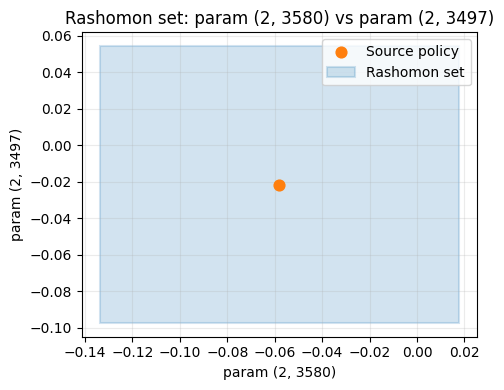

In [9]:
param_indices = [
    (sorted_final_param_bounds[0]['tensor_index'], sorted_final_param_bounds[0]['flat_index']),
    (sorted_final_param_bounds[1]['tensor_index'], sorted_final_param_bounds[1]['flat_index']),
]
source_params = (
    source_actor_params[param_indices[0][0]].flatten()[param_indices[0][1]].item(),
    source_actor_params[param_indices[1][0]].flatten()[param_indices[1][1]].item(),
)

plot_param_bounds(
    param_lower_bounds=final_param_bounds_l,
    param_upper_bounds=final_param_bounds_u,
    param_indices=param_indices,
    scatter_points=[
        {
            'coordinates': source_params,
            'color': 'tab:orange',
            'label': 'Source policy'
        },
    ],
    # source_params=source_params,
)

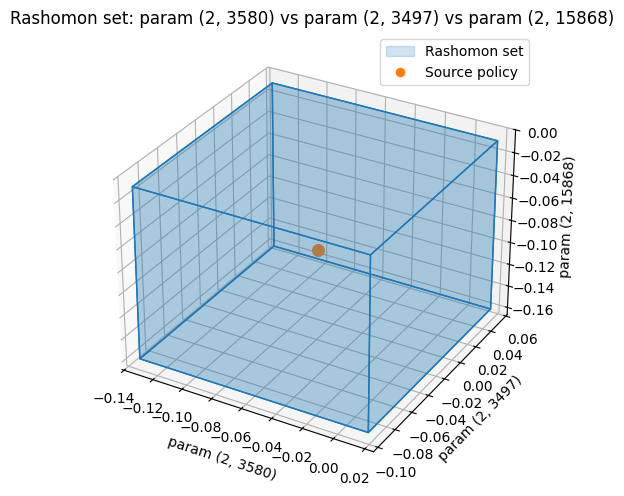

In [10]:
param_indices = [
    (sorted_final_param_bounds[0]['tensor_index'], sorted_final_param_bounds[0]['flat_index']),
    (sorted_final_param_bounds[1]['tensor_index'], sorted_final_param_bounds[1]['flat_index']),
    (sorted_final_param_bounds[2]['tensor_index'], sorted_final_param_bounds[2]['flat_index']),
]
source_params = (
    source_actor_params[param_indices[0][0]].flatten()[param_indices[0][1]].item(),
    source_actor_params[param_indices[1][0]].flatten()[param_indices[1][1]].item(),
    source_actor_params[param_indices[2][0]].flatten()[param_indices[2][1]].item(),
)

plot_param_bounds(
    param_lower_bounds=final_param_bounds_l,
    param_upper_bounds=final_param_bounds_u,
    param_indices=param_indices,
    scatter_points=[
        {
            'coordinates': source_params,
            'color': 'tab:orange',
            'label': 'Source policy'
        },
    ]
)

### Rashomon set per checkpoint

In [11]:
param_bounds_l_per_checkpoint = [
    [p.detach().cpu() for p in interval_trainer.bounds[i].param_l]
    for i in valid_indices
]
param_bounds_u_per_checkpoint = [
    [p.detach().cpu() for p in interval_trainer.bounds[i].param_u]
    for i in valid_indices
]

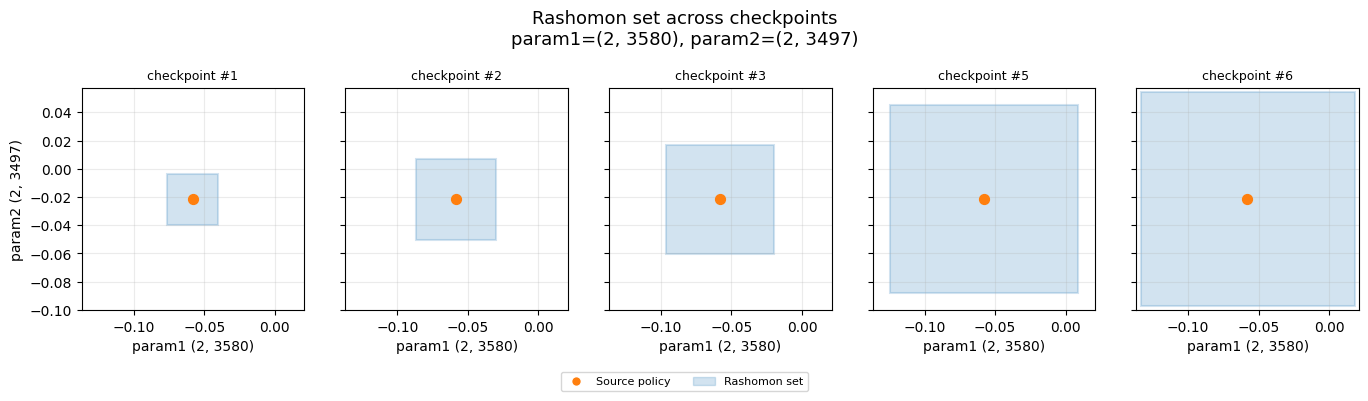

In [12]:
### 2D:
param_indices = [
    (sorted_final_param_bounds[0]["tensor_index"], sorted_final_param_bounds[0]["flat_index"]),
    (sorted_final_param_bounds[1]["tensor_index"], sorted_final_param_bounds[1]["flat_index"]),
]
source_params = (
    source_actor_params[param_indices[0][0]].flatten()[param_indices[0][1]].item(),
    source_actor_params[param_indices[1][0]].flatten()[param_indices[1][1]].item(),
)

plot_param_bounds_per_checkpoint(
    param_bounds_l_per_checkpoint=param_bounds_l_per_checkpoint,
    param_bounds_u_per_checkpoint=param_bounds_u_per_checkpoint,
    param_indices=param_indices,
    scatter_points=[
        {
            'coordinates': source_params,
            'color': 'tab:orange',
            'label': 'Source policy'
        }
    ],
    num_checkpoints_to_plot=5,
    n_rows=1,
)

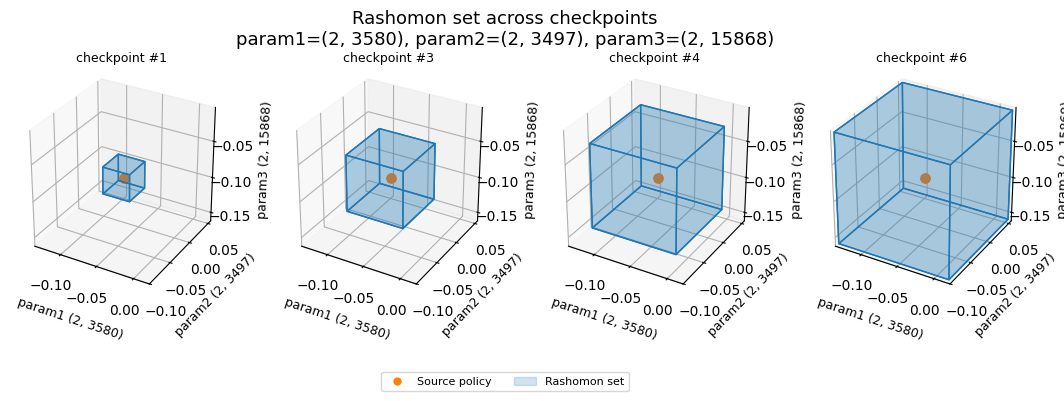

In [13]:
### 3D:
param_indices_3d = [
    (sorted_final_param_bounds[0]["tensor_index"], sorted_final_param_bounds[0]["flat_index"]),
    (sorted_final_param_bounds[1]["tensor_index"], sorted_final_param_bounds[1]["flat_index"]),
    (sorted_final_param_bounds[2]["tensor_index"], sorted_final_param_bounds[2]["flat_index"]),
]
source_params_3d = (
    source_actor_params[param_indices_3d[0][0]].flatten()[param_indices_3d[0][1]].item(),
    source_actor_params[param_indices_3d[1][0]].flatten()[param_indices_3d[1][1]].item(),
    source_actor_params[param_indices_3d[2][0]].flatten()[param_indices_3d[2][1]].item(),
)
plot_param_bounds_per_checkpoint(
    param_bounds_l_per_checkpoint=param_bounds_l_per_checkpoint,
    param_bounds_u_per_checkpoint=param_bounds_u_per_checkpoint,
    param_indices=param_indices_3d,
    scatter_points=[
        {
            'coordinates': source_params_3d,
            'color': 'tab:orange',
            'label': 'Source policy'
        }
    ],
    num_checkpoints_to_plot=4,
    n_rows=1,
)

### New Rashomon set

In [14]:
# Count scalar parameters represented by the bounded model
if "final_bounded_model" in globals():
    model_to_count = final_bounded_model
elif "bounded_model" in globals():
    model_to_count = bounded_model
elif "valid_bounds" in globals() and len(valid_bounds) > 0:
    model_to_count = valid_bounds[-1]
else:
    raise RuntimeError("No bounded model found. Run the Rashomon-bound computation first.")

if hasattr(model_to_count, "param_l"):
    n_params = sum(p.numel() for p in model_to_count.param_l)
elif hasattr(model_to_count, "parameters"):
    n_params = sum(p.numel() for p in model_to_count.parameters())
else:
    raise TypeError("Unsupported bounded model type for parameter counting.")

print(f"Number of parameters in bounded model: {n_params}")

Number of parameters in bounded model: 17540


In [15]:
import copy
import torch

new_base_actor = copy.deepcopy(source_actor).to(device)
with torch.no_grad():
    for p, l, u in zip(new_base_actor.parameters(), final_param_bounds_l, final_param_bounds_u):
        l = l.to(p.device).view_as(p)
        u = u.to(p.device).view_as(p)
        choose_u = torch.rand_like(l) < 0.5
        p.copy_(torch.where(choose_u, u, l))
new_base_actor.eval()

Sequential(
  (0): Linear(in_features=3, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=128, bias=True)
  (3): ReLU()
  (4): Linear(in_features=128, out_features=4, bias=True)
)

In [16]:
interval_trainer2 = IntervalTrainer(
    model=new_base_actor,
    min_acc_limit=surrogate_threshold,
    seed=seed,
    n_iters=rashomon_n_iters, # type: ignore
    min_acc_increment=0,
    T=selected_inverse_temp,
    checkpoint=checkpoint, # type: ignore
)
# multi_label = (max_valid_actions > 1.0)
interval_trainer2.compute_rashomon_set(
    dataset=rashomon_dataset,
    multi_label=True,
    aggregation=aggregation, # type: ignore
)

cert_min_threshold = 1.0
cert_values2 = [_certificate_to_float(cert) for cert in interval_trainer2.certificates]
valid_indices2 = [i for i, cert in enumerate(cert_values2) if cert >= cert_min_threshold]
if not valid_indices2:
    best_cert2 = max(cert_values2) if cert_values2 else float("-inf")
    raise ValueError(
        f"No Rashomon certificate satisfied cert_min_threshold={cert_min_threshold:.3f}. "
        f"Best certificate={best_cert2:.6f}",
    )

Initial acc constraint violation: -0.0440 (Positive = violated)
Number of model parameters: 17540
Computing Rashomon set with min acc limit: 0.50
Initial bbox:  Obj=0.00,  Size=0.00,  Min acc hard=1.00,  Min acc soft=0.54


  0%|          | 0/1000 [00:00<?, ?it/s, size=0.66, obj=0.000, min_soft_acc=0.516]

100%|██████████| 1000/1000 [00:13<00:00, 75.16it/s, size=2407.12, obj=0.137, min_soft_acc=0.501]


Final bbox:  Obj=0.14,  Size=2407.12,  Min acc hard=1.00,  Min acc soft=0.50
Computing final certificates over 256 samples
Num cert samples: 118
Checkpointed every 100 iterations for a total of 10 checkpoints
Checkpoints sizes: ['227.18', '524.54', '808.79', '1074.55', '1311.84', '1539.77', '1758.43', '1978.03', '2194.56', '2407.12']
Checkpoint certificates: ['0.00', '1.00', '1.00', '1.00', '1.00', '1.00', '0.00', '1.00', '0.00', '1.00']
Multitask certificates: []
----------------------- Finished Computing Rashomon set ------------------------


In [17]:
final_certificate_idx2 = valid_indices2[-1]
final_bounded_model2 = interval_trainer2.bounds[final_certificate_idx2]
final_param_bounds_l2 = [p.detach().cpu() for p in final_bounded_model2.param_l]
final_param_bounds_u2 = [p.detach().cpu() for p in final_bounded_model2.param_u]

sorted_final_param_bounds2 = sort_parameter_bounds_by_width(final_param_bounds_l2, final_param_bounds_u2)
pandas.DataFrame(sorted_final_param_bounds2).round(2)

,tensor_index,flat_index,width
0,2,14274,0.2
1,2,1730,0.2
2,2,14914,0.2
3,2,6978,0.2
4,2,15682,0.2
...,...,...,...
17535,4,380,0.0
17536,4,382,0.0
17537,4,383,0.0
17538,5,1,0.0


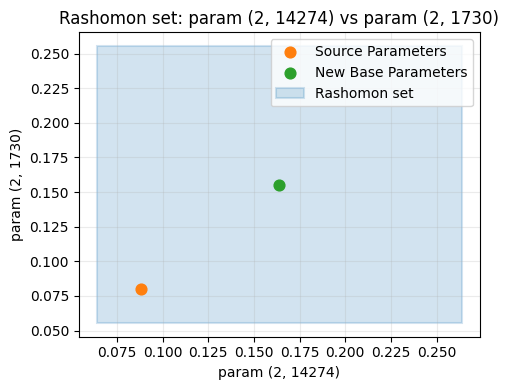

In [18]:
param_indices2 = [
    (sorted_final_param_bounds2[0]['tensor_index'], sorted_final_param_bounds2[0]['flat_index']),
    (sorted_final_param_bounds2[1]['tensor_index'], sorted_final_param_bounds2[1]['flat_index']),
]
source_params = (
    source_actor_params[param_indices2[0][0]].flatten()[param_indices2[0][1]].item(),
    source_actor_params[param_indices2[1][0]].flatten()[param_indices2[1][1]].item(),
)
new_base_params = (
    list(new_base_actor.parameters())[param_indices2[0][0]].flatten()[param_indices2[0][1]].item(),
    list(new_base_actor.parameters())[param_indices2[1][0]].flatten()[param_indices2[1][1]].item(),
)
scatter_points = [
    {
        'coordinates': source_params,
        'color': 'tab:orange',
        'label': 'Source Parameters'
    },
    {
        'coordinates': new_base_params,
        'color': 'tab:green',
        'label': 'New Base Parameters'
    }
]

plot_param_bounds(
    param_lower_bounds=final_param_bounds_l2,
    param_upper_bounds=final_param_bounds_u2,
    param_indices=param_indices2,
    scatter_points=scatter_points,
)

In [ ]:
from rl_project.utils.rashomon_utils import create_rashomon_set_video
# create_rashomon_set_video(
#     param_bounds_l_per_checkpoint=param_bounds_l_per_checkpoint,
#     param_bounds_u_per_checkpoint=param_bounds_u_per_checkpoint,
#     param_indices=param_indices2,
#     scatter_points=scatter_points,
#     output_path=artifact_dir / "rashomon_set_evolution.mp4",
# )

'/vol/bitbucket/ma5923/_projects/CertifiedContinualLearning/rl_project/experiments/frozenlake_scaled/notebooks/artifacts/diagonal_60x60/seed_0/rashomon_set_evolution.mp4'

### Two Rashomon sets

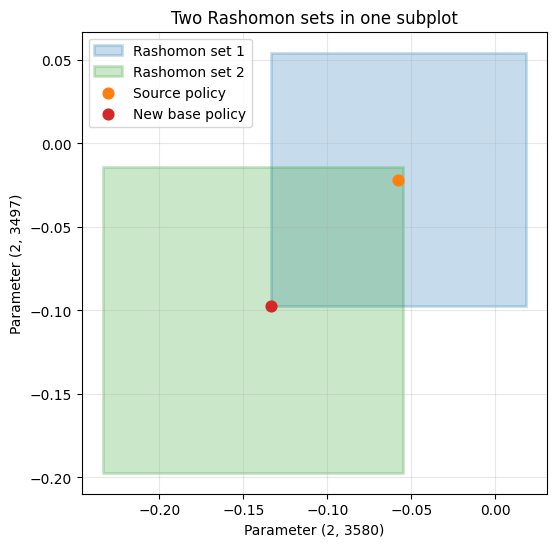

In [19]:
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt

# Use the two most uncertain shared parameters from the first Rashomon set
param_indices = [
    (sorted_final_param_bounds[0]["tensor_index"], sorted_final_param_bounds[0]["flat_index"]),
    (sorted_final_param_bounds[1]["tensor_index"], sorted_final_param_bounds[1]["flat_index"]),
]

def _get_param_value(params, tensor_idx, flat_idx):
    return params[tensor_idx].flatten()[flat_idx].item()

def _get_bounds(bounded_model, tensor_idx, flat_idx):
    lower = bounded_model.param_l[tensor_idx].detach().cpu().flatten()[flat_idx].item()
    upper = bounded_model.param_u[tensor_idx].detach().cpu().flatten()[flat_idx].item()
    return lower, upper

p1 = param_indices[0]
p2 = param_indices[1]

source_point = (
    _get_param_value(source_actor_params, *p1),
    _get_param_value(source_actor_params, *p2),
)
new_base_point = (
    _get_param_value(list(new_base_actor.parameters()), *p1),
    _get_param_value(list(new_base_actor.parameters()), *p2),
)

m1_x = _get_bounds(final_bounded_model, *p1)
m1_y = _get_bounds(final_bounded_model, *p2)
m2_x = _get_bounds(final_bounded_model2, *p1)
m2_y = _get_bounds(final_bounded_model2, *p2)

fig, ax = plt.subplots(figsize=(6, 6))

ax.add_patch(Rectangle(
    (m1_x[0], m1_y[0]),
    m1_x[1] - m1_x[0],
    m1_y[1] - m1_y[0],
    fill=True,
    edgecolor="tab:blue",
    facecolor="tab:blue",
    alpha=0.25,
    linewidth=2,
    label="Rashomon set 1",
))

ax.add_patch(Rectangle(
    (m2_x[0], m2_y[0]),
    m2_x[1] - m2_x[0],
    m2_y[1] - m2_y[0],
    fill=True,
    edgecolor="tab:green",
    facecolor="tab:green",
    alpha=0.25,
    linewidth=2,
    label="Rashomon set 2",
))

ax.scatter(*source_point, color="tab:orange", s=60, zorder=5, label="Source policy")
ax.scatter(*new_base_point, color="tab:red", s=60, zorder=5, label="New base policy")

ax.set_xlabel(f"Parameter {p1}")
ax.set_ylabel(f"Parameter {p2}")
ax.set_title("Two Rashomon sets in one subplot")
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

### Union of Rashomon sets

In [101]:
import torch

assert len(final_param_bounds_l) == len(final_param_bounds_l2)
new_final_param_bounds_l = [
    torch.minimum(a, b.to(a.device))
    for a, b in zip(final_param_bounds_l, final_param_bounds_l2)
]

new_final_param_bounds_u = [
    torch.maximum(a, b.to(a.device))
    for a, b in zip(final_param_bounds_u, final_param_bounds_u2)
]

In [102]:
first_param_info, second_param_info

({'tensor_idx': 4, 'flat_param_idx': 491, 'width': 1.6197240352630615},
 {'tensor_idx': 4, 'flat_param_idx': 107, 'width': 1.6192445755004883})

In [103]:
new_first_param_lower = new_final_param_bounds_l[first_param_info['tensor_idx']].flatten()[first_param_info['flat_param_idx']].item()
new_first_param_upper = new_final_param_bounds_u[first_param_info['tensor_idx']].flatten()[first_param_info['flat_param_idx']].item()
new_second_param_lower = new_final_param_bounds_l[second_param_info['tensor_idx']].flatten()[second_param_info['flat_param_idx']].item()
new_second_param_upper = new_final_param_bounds_u[second_param_info['tensor_idx']].flatten()[second_param_info['flat_param_idx']].item()

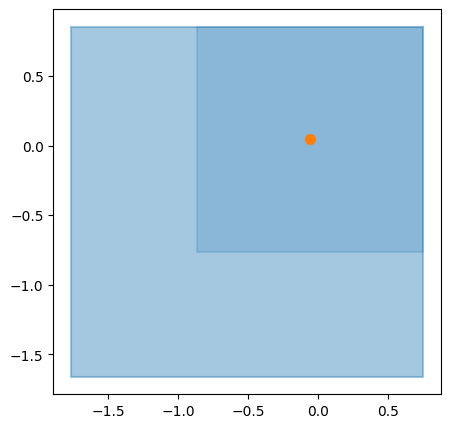

In [110]:
xb = first_param_bounds_per_checkpoint_to_plot[i]
yb = second_param_bounds_per_checkpoint_to_plot[i]

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(
    first_param_source_value,
    second_param_source_value,
    color="tab:orange",
    marker="o",
    s=50,
    label="Source policy",
    zorder=5,
)

# Previous
xb = first_param_bounds_per_checkpoint_to_plot[-1]
yb = second_param_bounds_per_checkpoint_to_plot[-1]
rect = Rectangle(
    (xb["lower"], yb["lower"]),
    xb["upper"] - xb["lower"],
    yb["upper"] - yb["lower"],
    fill=True,
    edgecolor="tab:blue",
    linewidth=1.5,
    alpha=0.2,
    label="Previous Rashomon set" if i == 0 else None,  # Only add label for legend on first plot
)
ax.add_patch(rect)

# Updated
rect = Rectangle(
    (new_first_param_lower, new_second_param_lower),
    new_first_param_upper - new_first_param_lower,
    new_second_param_upper - new_second_param_lower,
    fill=True,
    edgecolor="tab:blue",
    linewidth=1.5,
    alpha=0.4,
    label="Updated Rashomon set",
)
ax.add_patch(rect)

## OLD

In [ ]:
(
    param_bounds_l,
    param_bounds_u,
    bounded_model,
    selected_inverse_temp,
    surrogate_threshold,
    cert_values,
    selected_cert_idx,
) = compute_rashomon_bounds(
    actor=copy.deepcopy(source_actor).cpu(),
    rashomon_dataset=rashomon_dataset,
    seed=seed,
    rashomon_n_iters=rashomon_n_iters,
    aggregation=surrogate_aggregation,
    inverse_temp_start=inverse_temp_start,
    inverse_temp_max=inverse_temp_max,
    checkpoint=rashomon_checkpoint,
)

# print(f"Selected inverse temperature: {selected_inverse_temp}")
# print(f"Surrogate threshold: {surrogate_threshold:.6f}")
# print(f"Selected certificate index/value: {selected_cert_idx} / {cert_values[selected_cert_idx]:.6f}")
# print(f"Number of parameter tensors bounded: {len(param_bounds_l)}")

In [ ]:
rashomon_dataset_path = artifact_dir / "rashomon_dataset.pt"
state_action_pairs_path = artifact_dir / "source_policy_state_action_pairs.yaml"
bounded_model_path = artifact_dir / "bounded_model.pt"
param_bounds_path = artifact_dir / "param_bounds.pt"
summary_path = artifact_dir / "run_summary.yaml"

torch.save(rashomon_dataset, rashomon_dataset_path)
torch.save(bounded_model, bounded_model_path)
torch.save(
    {
        "param_bounds_l": [p.detach().cpu() for p in param_bounds_l],
        "param_bounds_u": [p.detach().cpu() for p in param_bounds_u],
    },
    param_bounds_path,
)
state_action_pairs_path.write_text(
    yaml.safe_dump(source_state_action_pairs, sort_keys=False),
    encoding="utf-8",
)

summary = {
    "layout": layout,
    "seed": int(seed),
    "source_checkpoint_dir": str(source_run_dir),
    "source_actor_checkpoint": str(actor_ckpt),
    "dataset_size": int(len(rashomon_dataset)),
    "trajectory_steps": int(len(source_state_action_pairs)),
    "rashomon_n_iters": int(rashomon_n_iters),
    "surrogate_aggregation": surrogate_aggregation,
    "inverse_temp_start": int(inverse_temp_start),
    "inverse_temp_max": int(inverse_temp_max),
    "selected_inverse_temp": int(selected_inverse_temp),
    "surrogate_threshold": float(surrogate_threshold),
    "selected_certificate_index": int(selected_cert_idx),
    "selected_certificate": float(cert_values[selected_cert_idx]),
    "all_certificates": [float(v) for v in cert_values],
    "rashomon_dataset_path": str(rashomon_dataset_path),
    "source_policy_state_action_pairs_path": str(state_action_pairs_path),
    "bounded_model_path": str(bounded_model_path),
    "param_bounds_path": str(param_bounds_path),
}
summary_path.write_text(yaml.safe_dump(summary, sort_keys=False), encoding="utf-8")

print(f"Saved rashomon dataset: {rashomon_dataset_path}")
print(f"Saved source state-action pairs: {state_action_pairs_path}")
print(f"Saved bounded model: {bounded_model_path}")
print(f"Saved param bounds: {param_bounds_path}")
print(f"Saved summary: {summary_path}")